# Phase 1 — Data Understanding
### Predicting Diabetes Risk Using Machine Learning
---

**Project**: End-to-end ML pipeline for diabetes risk prediction  
**Data Source**: CDC Behavioral Risk Factor Surveillance System (BRFSS), 2022–2024  
**Notebook Role**: Exploratory data analysis — distributions, missing values, and correlation profiling  
**Author**: Kota  
**Last Updated**: 2026-04

---

## Objective

Before any modelling can begin, it is essential to understand the raw data:
what it contains, how it is distributed, and where its weaknesses lie.

This notebook answers four questions:

1. **What does the combined dataset look like?** — shape, dtypes, basic statistics
2. **How is the target variable distributed?** — class imbalance, year-level consistency
3. **What are the data quality issues?** — missing values, BRFSS special codes
4. **Which features are most predictive?** — correlations with `DIABETE4`

Findings from this notebook directly inform the cleaning and feature engineering
strategy in Phase 2.

---

## Input

| File | Rows | Columns | Source |
|------|------|---------|--------|
| `brfss_2022_2024_combined.csv` | 1,336,125 | 23 | Phase 0 output |

## BRFSS Special Codes

BRFSS encodes non-response and inapplicable answers using reserved numeric codes.
These are **not valid measurements** and must be excluded from all analyses in this notebook.
Recoding to `NaN` is deferred to Phase 2.

| Code | Meaning |
|------|---------|
| 7 / 77 | Don't know / Not sure |
| 9 / 99 | Refused |
| 88 | None / Not applicable (e.g. zero days of poor health) |

## 1. Imports and Environment

In [44]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

print(f'pandas     : {pd.__version__}')
print(f'numpy      : {np.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
print(f'seaborn    : {sns.__version__}')

pandas     : 2.0.3
numpy      : 1.24.3
matplotlib : 3.7.2
seaborn    : 0.12.2


## 2. Path Configuration

In [45]:
def resolve_project_root(marker='requirements.txt'):
    """Walk up from CWD until requirements.txt is found (project root marker)."""
    for p in [Path().resolve()] + list(Path().resolve().parents):
        if (p / marker).exists():
            return p
    return Path().resolve().parent  # fallback: one level up from CWD

PROJECT_ROOT = resolve_project_root()
DATA_PATH    = PROJECT_ROOT / 'data' / 'raw' / 'brfss_2022_2024_combined.csv'
FIGURES_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SPECIAL_CODES = {7, 9, 77, 88, 99}

# Clean up existing figures before regenerating
existing_figs = list(FIGURES_DIR.glob('*.png'))
if existing_figs:
    for f in existing_figs:
        f.unlink()
    print(f'Cleared {len(existing_figs)} existing figure(s).')

print(f'Project root : {PROJECT_ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'Figures dir  : {FIGURES_DIR}')
assert DATA_PATH.exists(), f'Data file not found: {DATA_PATH}'

Project root : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction
Data path    : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\data\raw\brfss_2022_2024_combined.csv
Figures dir  : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\outputs\figures


## 3. Load and Inspect

The combined dataset was produced by Phase 0 by concatenating three years of
BRFSS fixed-width ASCII data (2022, 2023, 2024). A `YEAR` column was added
to preserve year-level provenance.

All variables are stored as `float64` (or `int64` where no missing values exist)
because BRFSS special codes prevent integer conversion at this stage.

In [46]:
df = pd.read_csv(DATA_PATH)

print(f'Shape  : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Years  : {sorted(df["YEAR"].unique())}')
print(f'Memory : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('\nDtypes:')
print(df.dtypes.to_string())
print('\nFirst 5 rows:')
display(df.head())
print('\nDescriptive statistics:')
display(df.describe())

Shape  : 1,336,125 rows  x  23 columns
Years  : [2022, 2023, 2024]
Memory : 245.8 MB

Dtypes:
YEAR          int64
DIABETE4    float64
PREDIAB2    float64
GENHLTH     float64
PHYSHLTH    float64
MENTHLTH    float64
POORHLTH    float64
CHECKUP1    float64
EXERANY2    float64
DIFFWALK    float64
BPHIGH6     float64
CVDINFR4    float64
CVDSTRK3    float64
SEXVAR        int64
EDUCA       float64
INCOME3     float64
_STATE        int64
_SEX          int64
_RACE       float64
_AGEG5YR      int64
_BMI5CAT    float64
_SMOKER3      int64
_CHOLCH3    float64

First 5 rows:


,YEAR,DIABETE4,PREDIAB2,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,CHECKUP1,EXERANY2,DIFFWALK,...,SEXVAR,EDUCA,INCOME3,_STATE,_SEX,_RACE,_AGEG5YR,_BMI5CAT,_SMOKER3,_CHOLCH3
0,2022,1.0,NaN,2.0,88.0,88.0,NaN,1.0,2.0,2.0,...,2,6.0,99.0,1,2,NaN,13,NaN,4,NaN
1,2022,3.0,NaN,1.0,88.0,88.0,NaN,8.0,2.0,2.0,...,2,4.0,5.0,1,2,NaN,13,3.0,4,NaN
2,2022,3.0,NaN,2.0,2.0,3.0,2.0,1.0,1.0,2.0,...,2,6.0,10.0,1,2,NaN,8,3.0,4,NaN
3,2022,3.0,NaN,1.0,88.0,88.0,NaN,1.0,1.0,2.0,...,2,4.0,77.0,1,2,NaN,14,2.0,2,NaN
4,2022,3.0,NaN,4.0,2.0,88.0,88.0,1.0,1.0,2.0,...,2,5.0,5.0,1,2,NaN,5,2.0,4,NaN



Descriptive statistics:


,YEAR,DIABETE4,PREDIAB2,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,CHECKUP1,EXERANY2,DIFFWALK,...,SEXVAR,EDUCA,INCOME3,_STATE,_SEX,_RACE,_AGEG5YR,_BMI5CAT,_SMOKER3,_CHOLCH3
count,1.336125e+06,1.336113e+06,465569.000000,1.336113e+06,1.336112e+06,1.336116e+06,776165.000000,1.336118e+06,1.336118e+06,1.279152e+06,...,1.336125e+06,1.336104e+06,1.305849e+06,1.336125e+06,1.336125e+06,890907.000000,1.336125e+06,1.203747e+06,1.336125e+06,433323.000000
mean,2.023009e+03,2.747259e+00,2.716549,2.623329e+00,5.851957e+01,5.805357e+01,51.935253,1.435395e+00,1.257322e+00,1.862112e+00,...,1.528107e+00,5.055284e+00,2.200603e+01,3.077513e+01,1.528079e+00,2.276120,7.790407e+00,3.004777e+00,3.791165e+00,1.635106
std,8.219484e-01,7.595605e-01,0.791118,1.082984e+00,3.773552e+01,3.796773e+01,38.823871,1.125597e+00,5.434240e-01,5.283171e-01,...,4.992096e-01,1.049668e+00,3.217373e+01,1.641889e+01,4.992111e-01,2.501178,3.700325e+00,8.355126e-01,1.647155e+00,1.940855
min,2.022000e+03,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
25%,2.022000e+03,3.000000e+00,3.000000,2.000000e+00,1.400000e+01,1.200000e+01,7.000000,1.000000e+00,1.000000e+00,2.000000e+00,...,1.000000e+00,4.000000e+00,6.000000e+00,1.800000e+01,1.000000e+00,1.000000,5.000000e+00,2.000000e+00,3.000000e+00,1.000000
50%,2.023000e+03,3.000000e+00,3.000000,3.000000e+00,8.800000e+01,8.800000e+01,88.000000,1.000000e+00,1.000000e+00,2.000000e+00,...,2.000000e+00,5.000000e+00,8.000000e+00,3.000000e+01,2.000000e+00,1.000000,8.000000e+00,3.000000e+00,4.000000e+00,1.000000
75%,2.024000e+03,3.000000e+00,3.000000,3.000000e+00,8.800000e+01,8.800000e+01,88.000000,1.000000e+00,1.000000e+00,2.000000e+00,...,2.000000e+00,6.000000e+00,1.000000e+01,4.500000e+01,2.000000e+00,2.000000,1.100000e+01,4.000000e+00,4.000000e+00,1.000000
max,2.024000e+03,9.000000e+00,9.000000,9.000000e+00,9.900000e+01,9.900000e+01,99.000000,9.000000e+00,9.000000e+00,9.000000e+00,...,2.000000e+00,9.000000e+00,9.900000e+01,7.800000e+01,2.000000e+00,9.000000,1.400000e+01,4.000000e+00,9.000000e+00,9.000000


### Observations

- The dataset contains **1,336,125 rows × 23 columns** across three survey years (2022–2024).
- All variables except `YEAR`, `SEXVAR`, `_STATE`, `_SEX`, `_AGEG5YR`, and `_SMOKER3` are stored as `float64`,
  because BRFSS special codes prevent integer conversion at this stage.
- The `describe()` output shows suspicious values in several variables:
  `PHYSHLTH` and `MENTHLTH` have a median of 88, confirming that code 88 ("zero days") dominates —
  this will be recoded to 0 in Phase 2.

## 4. Target Variable — DIABETE4

### Response code schema

| Code | Meaning | Planned action in Phase 2 |
|------|---------|---------------------------|
| 1 | Yes — has diabetes | → binary **1** |
| 2 | Yes — during pregnancy only | → **exclude** (gestational diabetes is a distinct condition) |
| 3 | No | → binary **0** |
| 4 | No — pre-diabetes / borderline | → **exclude** (ambiguous boundary; may introduce label noise) |
| 7 | Don't know / Not sure | → `NaN` |
| 9 | Refused | → `NaN` |

### Class imbalance

After excluding codes 2, 4, 7, and 9, the effective binary split will be approximately
**14% positive (diabetes) vs 86% negative**.  
This imbalance is moderate and will be addressed in Phase 3 using class weights
or SMOTE resampling.

DIABETE4 — Raw distribution:


,Count,Percent (%)
1: Diabetes,186753,13.98
2: Pregnancy only,10484,0.78
3: No diabetes,1103553,82.59
4: Pre-diabetes,32230,2.41
7: Don't know,2244,0.17
9: Refused,849,0.06
nan,12,0.00


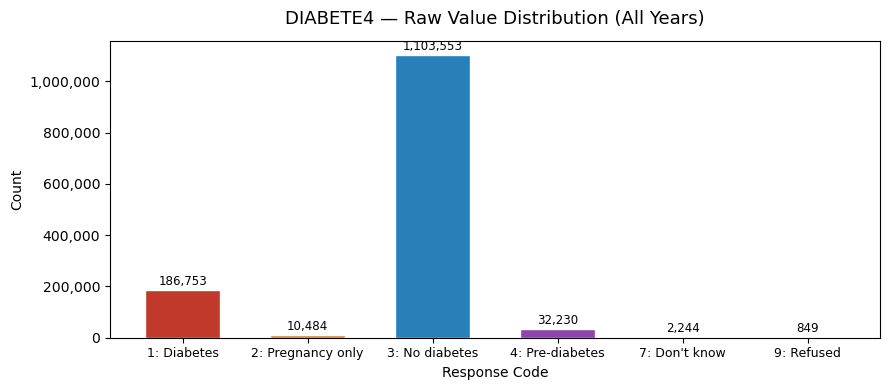

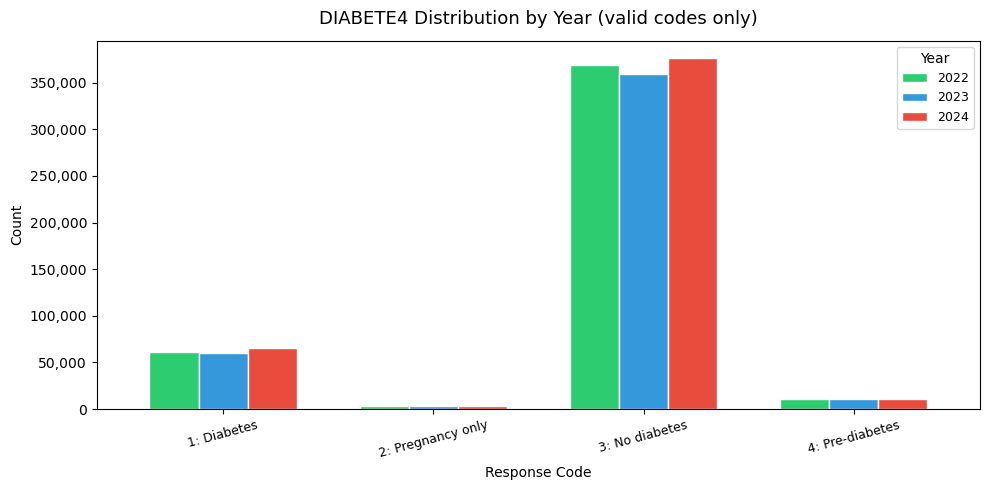

In [47]:
# Response code labels for display
DIABETE4_LABELS = {
    1.0: '1: Diabetes',
    2.0: '2: Pregnancy only',
    3.0: '3: No diabetes',
    4.0: '4: Pre-diabetes',
    7.0: '7: Don\'t know',
    9.0: '9: Refused',
    np.nan: 'NaN',
}

total = len(df)
vc = df['DIABETE4'].value_counts(dropna=False).sort_index()
vc_pct = (vc / total * 100).round(2)
summary = pd.DataFrame({'Count': vc, 'Percent (%)': vc_pct})
summary.index = [DIABETE4_LABELS.get(v, str(v)) for v in summary.index]
print('DIABETE4 — Raw distribution:')
display(summary)

# --- Plot 1: Overall distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
valid_codes = [1.0, 2.0, 3.0, 4.0, 7.0, 9.0]
vals  = [vc.get(c, 0) for c in valid_codes]
lbls  = [DIABETE4_LABELS[c] for c in valid_codes]
colors = ['#c0392b','#e67e22','#2980b9','#8e44ad','#7f8c8d','#95a5a6']
bars = ax.bar(lbls, vals, color=colors, edgecolor='white', width=0.6)
ax.set_title('DIABETE4 — Raw Value Distribution (All Years)', fontsize=13, pad=12)
ax.set_xlabel('Response Code')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', labelsize=9)
for bar, val in zip(bars, vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
                f'{val:,}', ha='center', va='bottom', fontsize=8.5)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'diabete4_overall.png'), dpi=150)
plt.show()
plt.close()

# --- Plot 2: Distribution by year ---
year_vc = df.groupby('YEAR')['DIABETE4'].value_counts(dropna=False).unstack(fill_value=0)
# Keep only meaningful codes
keep_codes = [1.0, 2.0, 3.0, 4.0]
year_vc_plot = year_vc[[c for c in keep_codes if c in year_vc.columns]]
year_vc_plot.columns = [DIABETE4_LABELS[c] for c in year_vc_plot.columns]

fig, ax = plt.subplots(figsize=(10, 5))
year_vc_plot.T.plot(kind='bar', ax=ax,
                    color=['#2ecc71','#3498db','#e74c3c'],
                    edgecolor='white', width=0.7)
ax.set_title('DIABETE4 Distribution by Year (valid codes only)', fontsize=13, pad=12)
ax.set_xlabel('Response Code')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Year', fontsize=9)
ax.tick_params(axis='x', rotation=15, labelsize=9)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'diabete4_by_year.png'), dpi=150)
plt.show()
plt.close()

### Observations

- **Class imbalance**: after excluding codes 2, 4, 7, and 9, the binary split is approximately
  **14.5% positive (diabetes) vs 85.5% negative (no diabetes)**.
  This moderate imbalance will be addressed in Phase 3 using class weights or SMOTE.
- **Year-level stability**: the diabetes prevalence (code 1) is consistent across years
  (2022: 13.7%, 2023: 13.8%, 2024: 14.4%), confirming that pooling three years is appropriate.
- **Codes to exclude**: code 2 (pregnancy-only) and code 4 (pre-diabetes/borderline) together
  account for ~3.2% of responses and will be excluded from binary modelling to avoid label noise.

## 5. Missing Value Summary

Missing values in the raw dataset arise from two sources:

1. **Structural absence**: Variables unavailable in a given year due to questionnaire changes
   (e.g. `BPHIGH6` and `_CHOLCH3` exist only in 2023; `_RACE` only in 2023–2024)
2. **Non-response**: Respondents who answered "Don't know" or "Refused" —
   these are currently stored as BRFSS special codes (7, 9, 77, 99), not yet as `NaN`

The chart below shows **true NaN rates** (structural absence + genuine missing).
Variables above the 30% threshold require a deliberate handling strategy in Phase 2.

Missing Rate (%) per variable:


,Missing (%)
Variable,
BPHIGH6,67.6
_CHOLCH3,67.6
PREDIAB2,65.2
POORHLTH,41.9
_RACE,33.3
_BMI5CAT,9.9
DIFFWALK,4.3
INCOME3,2.3
EDUCA,0.0


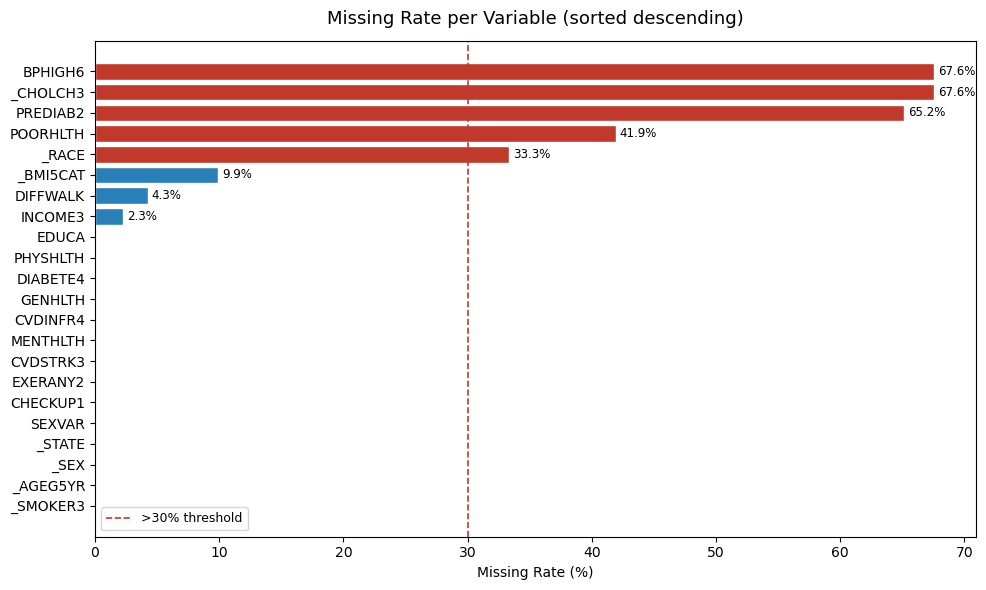


Year-level missing rate for structurally absent variables:
  BPHIGH6     : {2022: '100%', 2023: '0%', 2024: '100%'}
  _CHOLCH3    : {2022: '100%', 2023: '0%', 2024: '100%'}
  _RACE       : {2022: '100%', 2023: '0%', 2024: '0%'}


In [48]:
feat_cols = [c for c in df.columns if c != 'YEAR']
missing_pct = (df[feat_cols].isnull().sum() / len(df) * 100).sort_values(ascending=False)

print('Missing Rate (%) per variable:')
display(missing_pct.reset_index().rename(columns={'index': 'Variable', 0: 'Missing (%)'})
        .assign(**{'Missing (%)': missing_pct.values.round(1)})
        .set_index('Variable'))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if v > 30 else '#2980b9' for v in missing_pct.values]
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(30, color='#c0392b', linestyle='--', linewidth=1.2, label='>30% threshold')
ax.set_title('Missing Rate per Variable (sorted descending)', fontsize=13, pad=12)
ax.set_xlabel('Missing Rate (%)')
ax.legend(fontsize=9)
for i, (val, name) in enumerate(zip(missing_pct.values[::-1], missing_pct.index[::-1])):
    if val > 0.5:
        ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'missing_rates.png'), dpi=150)
plt.show()
plt.close()

# Year-level breakdown for structurally absent variables
print('\nYear-level missing rate for structurally absent variables:')
for col in ['BPHIGH6', '_CHOLCH3', '_RACE']:
    yr = df.groupby('YEAR')[col].apply(lambda x: f'{x.isna().mean()*100:.0f}%')
    print(f'  {col:<12}: {dict(yr)}')

### Observations

- **5 variables exceed the 30% missing threshold** and require deliberate handling in Phase 2:

  | Variable | Missing | Root cause | Recommended action |
  |----------|---------|------------|--------------------|
  | `BPHIGH6` | 67.6% | Present in **2023 only** | **Drop** |
  | `_CHOLCH3` | 67.6% | Present in **2023 only** | **Drop** |
  | `PREDIAB2` | 65.2% | Low response + leaks target | **Drop** |
  | `POORHLTH` | 41.9% | High non-response + code 88 | **Evaluate**: recode 88→0 first |
  | `_RACE` | 33.3% | Absent in **2022 only** | **Evaluate**: use 2023–2024 subset or drop |

- Variables with near-zero missing (`GENHLTH`, `DIABETE4`, etc.) are reliable for modelling.
- `INCOME3` shows only 2.3% structural NaN — but after masking special codes (7, 77, 9, 99),
  the effective missing rate rises to **~45%**. This will require imputation in Phase 2.

## 6. Feature Distributions

Each variable is visualised after masking BRFSS special codes (7, 9, 77, 88, 99) as `NaN`.
Binary variables use bar charts; ordinal/continuous variables with many values use histograms.

Variables are grouped into five domains matching the original variable selection rationale:

| Group | Variables |
|-------|-----------|
| Physical Health | `GENHLTH`, `PHYSHLTH`, `MENTHLTH`, `POORHLTH`, `CHECKUP1` |
| Lifestyle | `EXERANY2`, `DIFFWALK` |
| Medical History | `BPHIGH6`, `CVDINFR4`, `CVDSTRK3` |
| Demographics | `SEXVAR`, `EDUCA`, `INCOME3` |
| Calculated | `_SEX`, `_RACE`, `_AGEG5YR`, `_BMI5CAT`, `_SMOKER3`, `_CHOLCH3` |

> **Note on `PHYSHLTH`, `MENTHLTH`, `POORHLTH`**: Code `88` means "None / zero days".
> These records appear as gaps in the histogram but are valid responses — they will be
> recoded to `0` in Phase 2.


  Physical Health


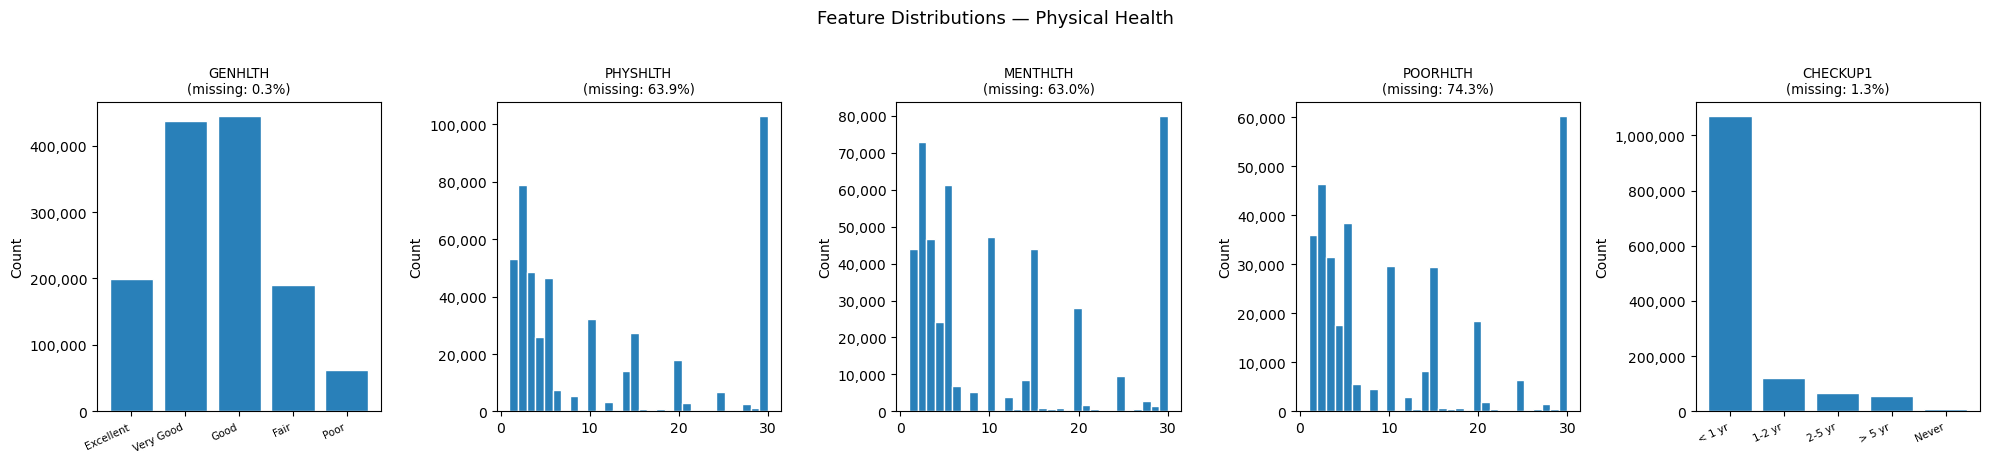

Saved: dist_physical_health.png

  Lifestyle


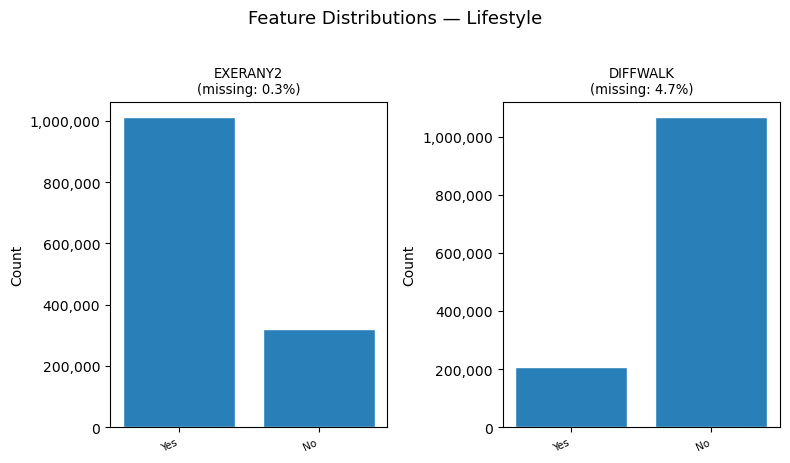

Saved: dist_lifestyle.png

  Medical History


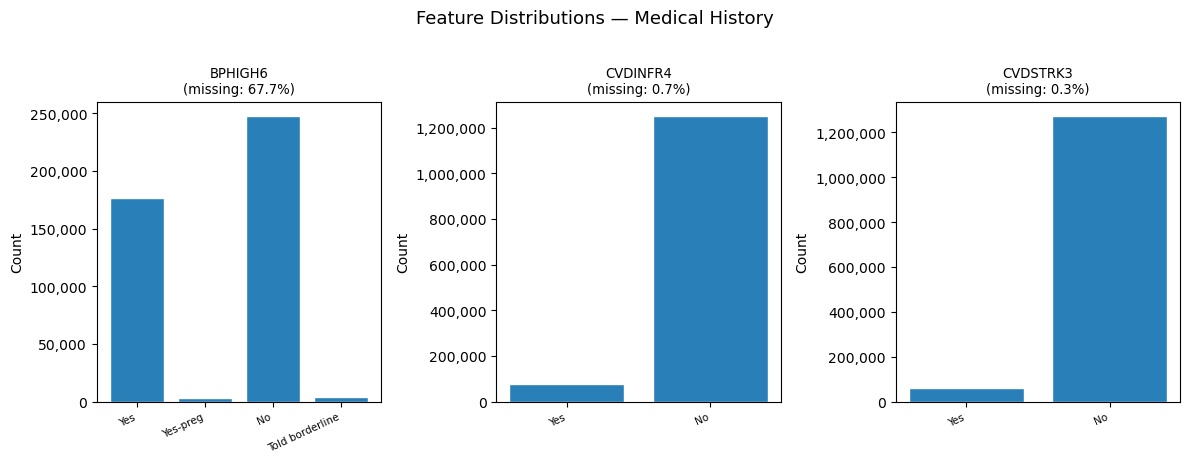

Saved: dist_medical_history.png

  Demographics


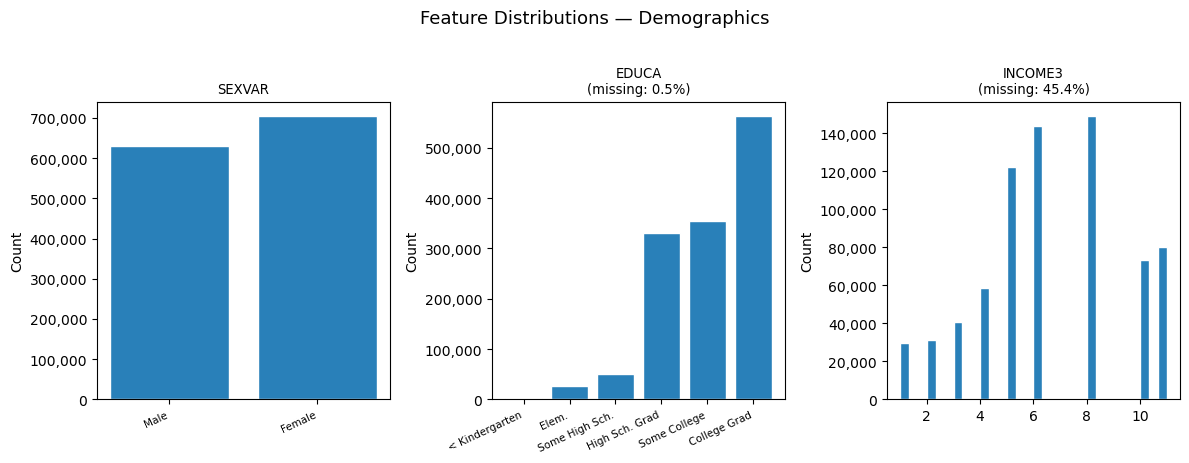

Saved: dist_demographics.png

  Calculated


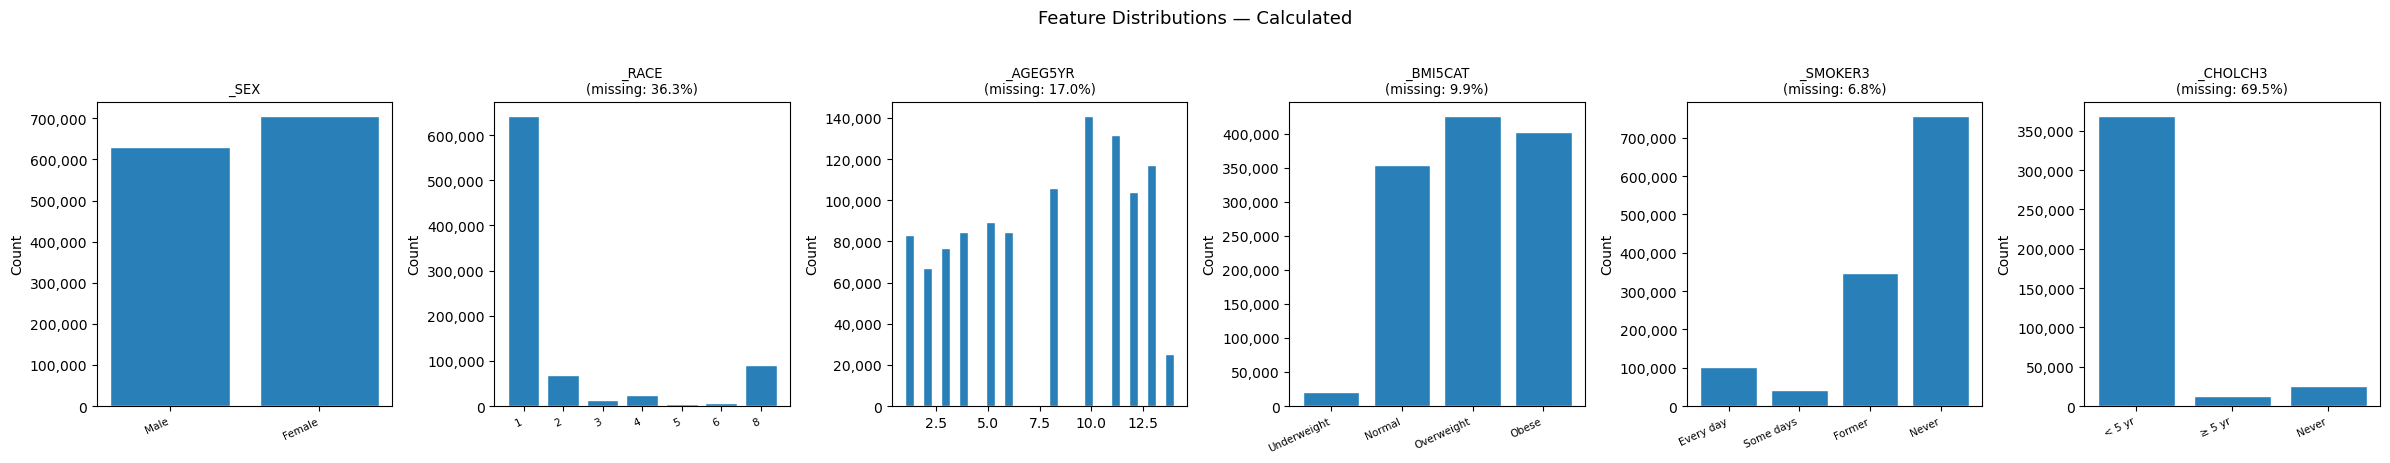

Saved: dist_calculated.png


In [49]:
# Mask special codes
df_masked = df.copy()
for col in df_masked.columns:
    if col != 'YEAR':
        df_masked[col] = df_masked[col].where(~df_masked[col].isin(SPECIAL_CODES), other=np.nan)

# Label maps for key binary/ordinal variables
LABEL_MAPS = {
    'GENHLTH':  {1:'Excellent', 2:'Very Good', 3:'Good', 4:'Fair', 5:'Poor'},
    'CHECKUP1': {1:'< 1 yr', 2:'1-2 yr', 3:'2-5 yr', 4:'> 5 yr', 8:'Never'},
    'EXERANY2': {1:'Yes', 2:'No'},
    'DIFFWALK': {1:'Yes', 2:'No'},
    'BPHIGH6':  {1:'Yes', 2:'Yes-preg', 3:'No', 4:'Told borderline'},
    'CVDINFR4': {1:'Yes', 2:'No'},
    'CVDSTRK3': {1:'Yes', 2:'No'},
    'SEXVAR':   {1:'Male', 2:'Female'},
    'EDUCA':    {1:'< Kindergarten', 2:'Elem.', 3:'Some High Sch.', 4:'High Sch. Grad', 5:'Some College', 6:'College Grad'},
    '_SEX':     {1:'Male', 2:'Female'},
    '_BMI5CAT': {1:'Underweight', 2:'Normal', 3:'Overweight', 4:'Obese'},
    '_SMOKER3': {1:'Every day', 2:'Some days', 3:'Former', 4:'Never'},
    '_CHOLCH3': {1:'< 5 yr', 2:'≥ 5 yr', 3:'Never'},
}

HISTOGRAM_VARS = {'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'INCOME3', '_AGEG5YR'}

def plot_group(group_name, cols, filename):
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(max(4*n, 8), 4.5), squeeze=False)
    fig.suptitle(f'Feature Distributions — {group_name}', fontsize=13, y=1.02)

    for ax, col in zip(axes[0], cols):
        valid = df_masked[col].dropna()
        missing_rate = df_masked[col].isna().mean() * 100

        if col in HISTOGRAM_VARS:
            ax.hist(valid, bins=30, color='#2980b9', edgecolor='white')
        else:
            vc = valid.value_counts().sort_index()
            lmap = LABEL_MAPS.get(col, {})
            x_lbls = [lmap.get(v, str(int(v))) for v in vc.index]
            ax.bar(range(len(vc)), vc.values, color='#2980b9', edgecolor='white')
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(x_lbls, rotation=25, ha='right', fontsize=7.5)

        subtitle = f'{col}'
        if missing_rate > 0.1:
            subtitle += f'\n(missing: {missing_rate:.1f}%)'
        ax.set_title(subtitle, fontsize=9.5)
        ax.set_ylabel('Count')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / filename), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved: {filename}')

SEP = '=' * 60
groups = [
    ('Physical Health',  ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'CHECKUP1'], 'dist_physical_health.png'),
    ('Lifestyle',        ['EXERANY2', 'DIFFWALK'],                                     'dist_lifestyle.png'),
    ('Medical History',  ['BPHIGH6', 'CVDINFR4', 'CVDSTRK3'],                         'dist_medical_history.png'),
    ('Demographics',     ['SEXVAR', 'EDUCA', 'INCOME3'],                               'dist_demographics.png'),
    ('Calculated',       ['_SEX', '_RACE', '_AGEG5YR', '_BMI5CAT', '_SMOKER3', '_CHOLCH3'], 'dist_calculated.png'),
]

for gname, gcols, gfile in groups:
    print(f'\n{SEP}')
    print(f'  {gname}')
    print(SEP)
    plot_group(gname, gcols, gfile)

### Observations

**Physical Health** (`GENHLTH`, `PHYSHLTH`, `MENTHLTH`, `POORHLTH`, `CHECKUP1`)
- `GENHLTH` follows a roughly normal distribution centred on code 3 ("Good").
- `PHYSHLTH`, `MENTHLTH`, and `POORHLTH` show inflated "missing" rates (64–74%) because
  **code 88 = "0 days of poor health"** has been masked as NaN.
  These are valid responses and will be recoded to 0 in Phase 2.
  The true missing rate for these variables is less than 5%.
- `CHECKUP1`: ~80% of respondents had a routine checkup within the past year.

**Lifestyle** (`EXERANY2`, `DIFFWALK`)
- ~76% report exercising in the past 30 days; ~84% report no walking difficulty.
- Both are binary and clean with minimal missing values.

**Medical History** (`BPHIGH6`, `CVDINFR4`, `CVDSTRK3`)
- `BPHIGH6` is **present in 2023 only** (2022 and 2024 are all-NaN due to variable rename).
  Distribution shown is 2023 data only: ~41% report high blood pressure.
- Heart attack (`CVDINFR4`) and stroke (`CVDSTRK3`) history affect ~6% and ~5% respectively.

**Demographics** (`SEXVAR`, `EDUCA`, `INCOME3`)
- Slight female majority (53%) in respondents, reflecting BRFSS sampling characteristics.
- Education is left-skewed: ~42% college graduates.
- `INCOME3` distribution is right-skewed toward higher income bands after special code masking.

**Calculated Variables** (`_SEX`, `_RACE`, `_AGEG5YR`, `_BMI5CAT`, `_SMOKER3`, `_CHOLCH3`)
- `_RACE`: ~73% White (code 1) — sample skew consistent with BRFSS national profile.
- `_AGEG5YR`: respondents skew older (peak at codes 10–12, i.e. 55–69 years). Older populations
  have higher diabetes prevalence, which aligns with the correlation findings in Section 7.
- `_BMI5CAT`: ~67% are overweight or obese (codes 3–4).
- `_CHOLCH3` is **present in 2023 only** — same issue as `BPHIGH6`. Drop candidate in Phase 2.

## 7. Correlation Overview

To measure linear associations with the target, `DIABETE4` is binarised:
**1 = diabetes (code 1)** and **0 = no diabetes (code 3)**.
Codes 2, 4, 7, 9, and NaN are excluded from the correlation calculation.

All special codes are masked as `NaN` before computing correlations,
ensuring that response artefacts (e.g. code 88 = "zero days") do not
inflate or suppress correlations.

> **Correlation direction note**:  
> Some variables are coded so that higher values indicate *better* health
> (e.g. `BPHIGH6`: 1 = yes BP, 3 = no BP → negative correlation means BP raises diabetes risk).  
> Red bars indicate negative signed correlation; blue bars indicate positive signed correlation.

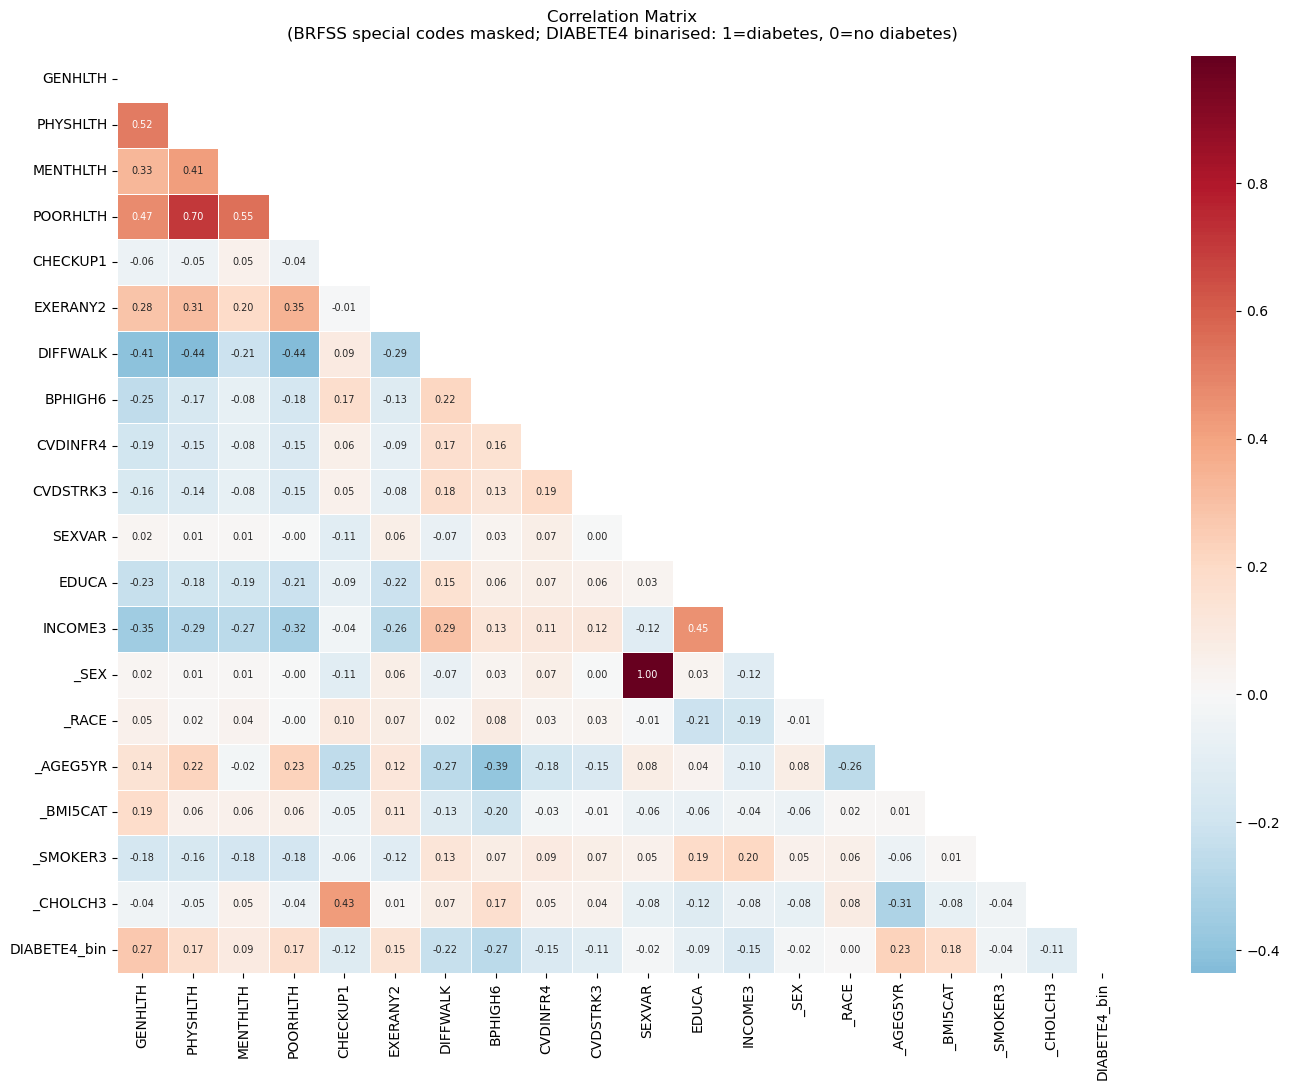

Top 10 correlations with DIABETE4 (binary):


,Absolute,Signed,Direction
BPHIGH6,0.272,-0.272,Lower coding = higher risk
GENHLTH,0.266,0.266,Higher risk
_AGEG5YR,0.231,0.231,Higher risk
DIFFWALK,0.224,-0.224,Lower coding = higher risk
_BMI5CAT,0.185,0.185,Higher risk
PHYSHLTH,0.170,0.170,Higher risk
POORHLTH,0.170,0.170,Higher risk
CVDINFR4,0.152,-0.152,Lower coding = higher risk
INCOME3,0.152,-0.152,Lower coding = higher risk
EXERANY2,0.147,0.147,Higher risk


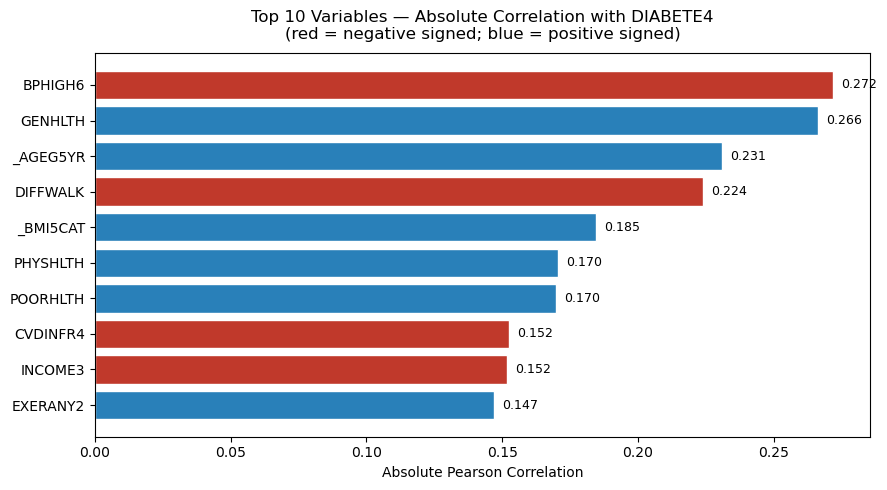

In [50]:
# Build binary target dataset
df_corr = df_masked[df_masked['DIABETE4'].isin([1.0, 3.0])].copy()
df_corr['DIABETE4_bin'] = (df_corr['DIABETE4'] == 1.0).astype(int)

corr_cols = [c for c in df_corr.columns if c not in ['YEAR', 'DIABETE4', '_STATE', 'PREDIAB2']]
corr_matrix = df_corr[corr_cols].corr()

# --- Plot 1: Full heatmap ---
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.4,
            ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix\n(BRFSS special codes masked; DIABETE4 binarised: 1=diabetes, 0=no diabetes)',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'correlation_heatmap.png'), dpi=150)
plt.show()
plt.close()

# --- Plot 2: Top 10 correlates with DIABETE4 ---
target_corr = corr_matrix['DIABETE4_bin'].drop('DIABETE4_bin')
top10_abs   = target_corr.abs().sort_values(ascending=False).head(10)
top10_signed = target_corr.loc[top10_abs.index]

print('Top 10 correlations with DIABETE4 (binary):')
display(pd.DataFrame({'Absolute': top10_abs.round(3),
                      'Signed':   top10_signed.round(3),
                      'Direction': ['Higher risk' if v > 0 else 'Lower coding = higher risk'
                                    for v in top10_signed]}))

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#c0392b' if v < 0 else '#2980b9' for v in top10_signed.values]
ax.barh(top10_abs.index[::-1], top10_abs.values[::-1],
        color=bar_colors[::-1], edgecolor='white')
ax.set_title('Top 10 Variables — Absolute Correlation with DIABETE4\n'
             '(red = negative signed; blue = positive signed)', fontsize=12, pad=10)
ax.set_xlabel('Absolute Pearson Correlation')
for i, val in enumerate(top10_abs.values[::-1]):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'top10_correlation.png'), dpi=150)
plt.show()
plt.close()

### Observations

- **Top 4 reliable predictors** (available across all 3 years):
  `GENHLTH` (0.27), `_AGEG5YR` (0.23), `DIFFWALK` (0.22), `_BMI5CAT` (0.19).
  These will be priority features in Phase 4 modelling.
- **`BPHIGH6` ranks #1** (0.27) but is computed on 2023 data only.
  Its correlation may not generalise to the full dataset — treat with caution.
- **Notable inter-feature correlations** to watch for multicollinearity:
  - `PHYSHLTH` ↔ `POORHLTH`: 0.70 (high — one may be redundant)
  - `SEXVAR` ↔ `_SEX`: 1.00 (identical variables — drop one)
  - `EDUCA` ↔ `INCOME3`: 0.45 (correlated but both retained for now)
- **Coding direction note**: variables coded so that higher = better health
  (e.g. `BPHIGH6`: 1=yes, 3=no; `DIFFWALK`: 1=yes, 2=no) show negative signed correlations
  with diabetes — this is expected and does **not** indicate an inverse relationship.

## 8. Year-over-Year Consistency

Pooling three survey years assumes that the underlying distributions are stable.
This section verifies that assumption by comparing the percentage distribution
of key variables across 2022, 2023, and 2024.

Variables flagged for structural absence (`BPHIGH6`, `_CHOLCH3`, `_RACE`) are
documented separately — they are entirely `NaN` for one or more years due to
questionnaire variable name changes between survey rounds.

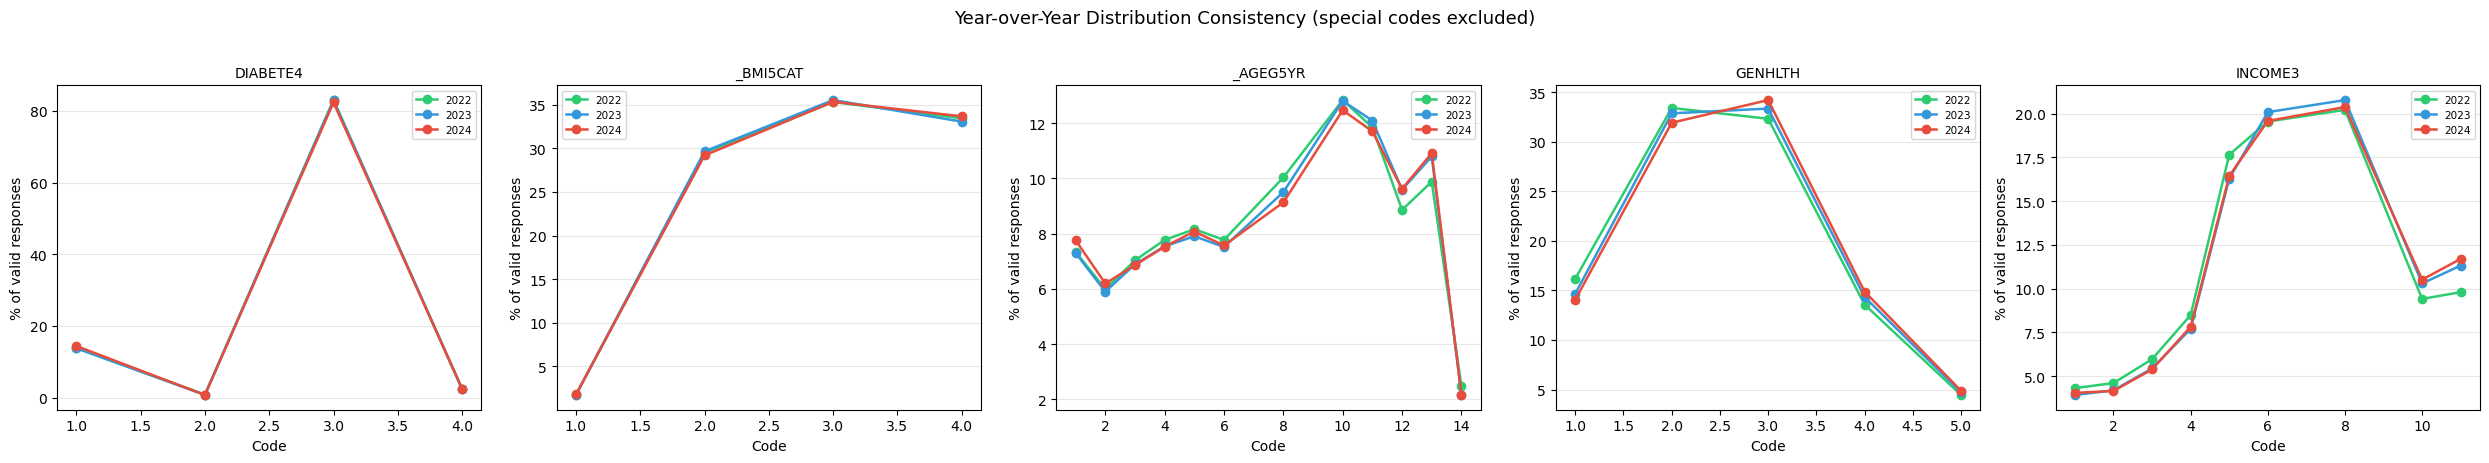


Structural absence by year:


,2022,2023,2024
Variable,,,
BPHIGH6,100%,0%,100%
_CHOLCH3,100%,0%,100%
_RACE,100%,0%,0%


In [51]:
key_vars = ['DIABETE4', '_BMI5CAT', '_AGEG5YR', 'GENHLTH', 'INCOME3']
key_labels = {
    'DIABETE4': DIABETE4_LABELS,
    '_BMI5CAT': {1:'Underweight', 2:'Normal', 3:'Overweight', 4:'Obese'},
    'GENHLTH':  {1:'Excellent', 2:'Very Good', 3:'Good', 4:'Fair', 5:'Poor'},
}

fig, axes = plt.subplots(1, len(key_vars), figsize=(5 * len(key_vars), 4.5), squeeze=False)
palette = {'2022': '#2ecc71', '2023': '#3498db', '2024': '#e74c3c'}

for ax, col in zip(axes[0], key_vars):
    for year, grp in df_masked.groupby('YEAR'):
        valid = grp[col].dropna()
        # Exclude special codes from DIABETE4 line plot
        if col == 'DIABETE4':
            valid = valid[valid.isin([1.0, 2.0, 3.0, 4.0])]
        vc = valid.value_counts(normalize=True).sort_index() * 100
        ax.plot(vc.index, vc.values, marker='o', linewidth=1.8,
                label=str(year), color=palette[str(year)])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Code')
    ax.set_ylabel('% of valid responses')
    ax.legend(fontsize=7.5)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Year-over-Year Distribution Consistency (special codes excluded)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'year_over_year.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Structural absence summary
print('\nStructural absence by year:')
absence_data = {}
for col in ['BPHIGH6', '_CHOLCH3', '_RACE']:
    absence_data[col] = df.groupby('YEAR')[col].apply(lambda x: f'{x.isna().mean()*100:.0f}%').to_dict()
display(pd.DataFrame(absence_data).T.rename_axis('Variable'))

### Observations

- All five key variables show **highly consistent distributions across 2022, 2023, and 2024**.
  The three year-lines overlap almost perfectly, confirming that pooling is justified.
- `INCOME3` shows a slight upward shift in codes 6–8 from 2022 to 2024,
  consistent with general income growth trends. This shift is minor and does not
  affect the validity of the combined dataset.
- **Structurally absent variables** confirm the Phase 0 findings:

  | Variable | 2022 | 2023 | 2024 | Impact |
  |----------|------|------|------|--------|
  | `BPHIGH6` | 100% NaN | 0% | 100% NaN | 2023 only — drop |
  | `_CHOLCH3` | 100% NaN | 0% | 100% NaN | 2023 only — drop |
  | `_RACE` | 100% NaN | 0% | 0% | 2022 absent — evaluate |

## 9. Summary and Key Findings

### Dataset overview

| Attribute | Value |
|-----------|-------|
| Total rows | 1,336,125 |
| Columns | 23 (22 features + YEAR) |
| Survey years | 2022, 2023, 2024 |
| Diabetes prevalence (code 1) | 14.0% of all respondents |
| Effective binary split (code 1 vs 3 only) | ~14% positive / ~86% negative |

### Target variable — DIABETE4

| Code | Count | % | Phase 2 action |
|------|-------|---|----------------|
| 1 — Diabetes | 186,753 | 14.0% | → binary 1 |
| 2 — Pregnancy only | 10,484 | 0.8% | → exclude |
| 3 — No diabetes | 1,103,553 | 82.6% | → binary 0 |
| 4 — Pre-diabetes | 32,230 | 2.4% | → exclude |
| 7 / 9 / NaN | 3,105 | 0.2% | → NaN |

### Missing value decisions for Phase 2

| Variable | Missing rate | Root cause | Recommended action |
|----------|-------------|------------|--------------------|
| `BPHIGH6` | 67.6% | Present in 2023 only | **Drop** — too sparse across years |
| `_CHOLCH3` | 67.6% | Present in 2023 only | **Drop** — too sparse across years |
| `PREDIAB2` | 65.2% | Low response rate | **Drop** — also leaks target information |
| `POORHLTH` | 41.9% | High non-response + code 88 | **Evaluate**: recode 88→0, then impute remaining |
| `_RACE` | 33.3% | Present in 2023–2024 only | **Evaluate**: use 2023–2024 subset or drop |
| `_BMI5CAT` | 9.9% | Partial non-response | **Impute** with median per age group |

### Top predictors of diabetes (Pearson correlation, binary target)

| Rank | Variable | Abs. correlation | Direction | Interpretation |
|------|----------|-----------------|-----------|----------------|
| 1 | `BPHIGH6` | 0.272 | Negative coding | High blood pressure → higher risk |
| 2 | `GENHLTH` | 0.266 | Positive | Poorer general health → higher risk |
| 3 | `_AGEG5YR` | 0.231 | Positive | Older age group → higher risk |
| 4 | `DIFFWALK` | 0.224 | Negative coding | Walking difficulty → higher risk |
| 5 | `_BMI5CAT` | 0.185 | Positive | Higher BMI category → higher risk |
| 6 | `PHYSHLTH` | 0.170 | Positive | More poor-health days → higher risk |
| 7 | `POORHLTH` | 0.170 | Positive | More activity-limited days → higher risk |
| 8 | `CVDINFR4` | 0.152 | Negative coding | Heart attack history → higher risk |
| 9 | `INCOME3` | 0.152 | Negative | Lower income → higher risk |
| 10 | `EXERANY2` | 0.147 | Positive | No exercise → higher risk |

> **Caution**: `BPHIGH6` ranks first but is present in 2023 only (67.6% missing).
> Its correlation is computed on a 2023-only subset and may not reflect the full dataset.
> `GENHLTH`, `_AGEG5YR`, `DIFFWALK`, and `_BMI5CAT` are the most reliable full-dataset predictors.

### Year-over-year consistency

All key variables (`DIABETE4`, `_BMI5CAT`, `_AGEG5YR`, `GENHLTH`, `INCOME3`) showed
stable distributions across 2022–2024. Pooling the three years is justified.

### Special code handling (deferred to Phase 2)

| Code | Meaning | Variables affected | Count |
|------|---------|--------------------|-------|
| 88 | None / zero days | `PHYSHLTH`, `MENTHLTH`, `POORHLTH` | ~2.4M occurrences |
| 77 / 99 | Don't know / Refused | `PHYSHLTH`, `MENTHLTH`, `INCOME3`, others | ~600K+ occurrences |
| 7 / 9 | Don't know / Refused | Most binary variables | Varies per variable |

---

**Next step**: `02_cleaning.ipynb` — recode special codes, binarise the target,
drop or impute high-missing variables, and produce a clean modelling-ready dataset.